In [1]:
# Day 27 - Bias-Variance Analysis

import numpy as np
import pandas as pd

np.random.seed(42)
n = 100

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "Income": np.random.randint(20000, 100000, n),
    "Purchase_Amount": np.random.randint(500, 5000, n),
    "Savings": np.random.randint(5000, 50000, n),
    "Credit_Score": np.random.randint(300, 850, n)
})

df["Purchased"] = (
    (df["Purchase_Amount"] > 2000) |
    (df["Age"] < 25)
).astype(int)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (100, 6)


,Age,Income,Purchase_Amount,Savings,Credit_Score,Purchased
0,56,28392,646,16093,393,0
1,46,50535,3719,23070,752,1
2,32,98603,3411,40777,503,1
3,25,72256,2234,21538,517,1
4,38,55222,2343,15729,773,1


In [2]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (100, 5)
Target Shape: (100,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Validation Set:", X_val.shape)

Training Set: (80, 5)
Validation Set: (20, 5)


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [1, 3, 5, 10]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_accuracy = accuracy_score(y_train, train_pred)
    val_accuracy = accuracy_score(y_val, val_pred)
    
    results.append({
        "Max Depth": depth,
        "Training Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy
    })

results_df = pd.DataFrame(results)

print(results_df)

   Max Depth  Training Accuracy  Validation Accuracy
0          1              0.975                  1.0
1          3              1.000                  1.0
2          5              1.000                  1.0
3         10              1.000                  1.0


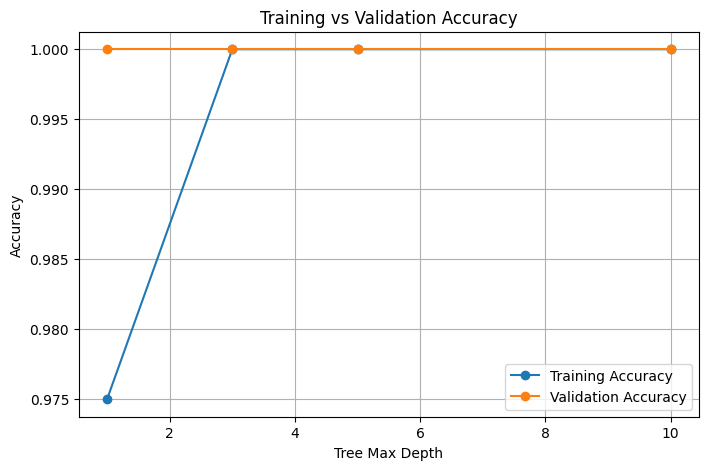

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Max Depth"],
    results_df["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    results_df["Max Depth"],
    results_df["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Tree Max Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()


In [6]:
from sklearn.model_selection import learning_curve

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

train_sizes, train_scores, validation_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

print("Training Scores:", train_mean)
print("Validation Scores:", validation_mean)

Training Scores: [1. 1. 1. 1. 1.]
Validation Scores: [0.65 0.96 0.97 0.99 1.  ]


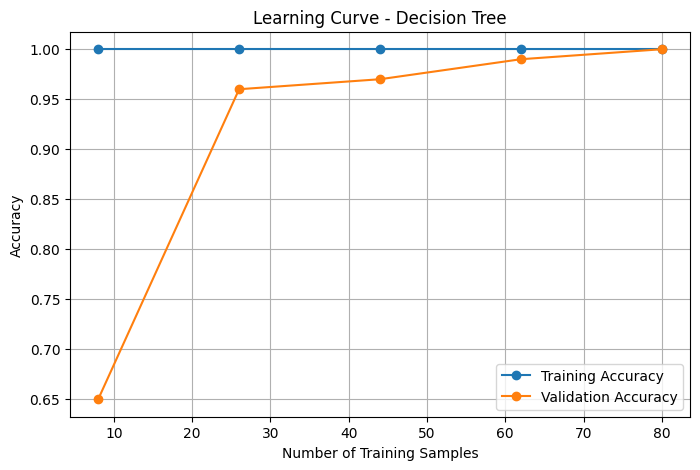

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Decision Tree")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
learning_curve_results = pd.DataFrame({
    "Training Samples": train_sizes,
    "Training Accuracy": train_mean,
    "Validation Accuracy": validation_mean
})

learning_curve_results.to_csv(
    "day27_learning_curve_results.csv",
    index=False
)

print(learning_curve_results)
print("\nLearning curve results saved successfully!")

   Training Samples  Training Accuracy  Validation Accuracy
0                 8                1.0                 0.65
1                26                1.0                 0.96
2                44                1.0                 0.97
3                62                1.0                 0.99
4                80                1.0                 1.00

Learning curve results saved successfully!


In [9]:
results_df.to_csv(
    "day27_model_complexity_comparison.csv",
    index=False
)

print("Model complexity comparison saved successfully!")

Model complexity comparison saved successfully!
